#### Elliptic Envelop

Elliptic Envelope is an unsupervised anomaly detection algorithm obtained from sklearn.covariance

It assumes:

(a.)    Normal data follows a Gaussian (Normal) distribution

(b.)    Outliers lie far away from the data distribution

(c.)    Data forms an elliptical shape in multidimensional space

It uses:

(a.)    Robust covariance estimation

(b.)    Mahalanobis Distance

to identify anomalies.


#### Problem Statement :-----

1.  Develop an Anamoly based system on breast cancer dataset using Local Outlier Factor algorithm and predict

    (a.)    all the outliers and the elliptic scores

#### Step 1: Import all the necessary libraries

In [620]:
import  numpy               as  np
import  pandas              as  pd
import  matplotlib.pyplot   as  plt
import  seaborn             as  sns

from    sklearn.datasets             import     load_breast_cancer
from    sklearn.model_selection      import     train_test_split
from    sklearn.preprocessing        import     StandardScaler
from    sklearn.covariance           import     EllipticEnvelope

#### Step 2:    Load the dataset

In [621]:
#### extract the data

data = load_breast_cancer()

#### constuct the dataframe from the data
df = pd.DataFrame(data.data, columns=data.feature_names)

#### Add the target to the dataset
df['target'] = data.target

df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


#### OBSERVATIONS:

1.  There are total 569 records in the dataset.

2.  The dataset has 569 rows and 31 columns.

3.  ### Dataset Interpretation 

| Column Name             | One-Line Explanation                                                 |
| ----------------------- | -------------------------------------------------------------------- |
| mean radius             | Average distance from the center to the perimeter of the tumor cells |
| mean texture            | Average variation in gray-scale intensity of the cell image          |
| mean perimeter          | Average perimeter length of the tumor nucleus                        |
| mean area               | Average area occupied by the tumor nucleus                           |
| mean smoothness         | Average smoothness of cell boundaries                                |
| mean compactness        | Average compactness = perimeter² / area − 1                          |
| mean concavity          | Average severity of concave portions in the contour                  |
| mean concave points     | Average number of concave portions of the contour                    |
| mean symmetry           | Average symmetry of the cell shape                                   |
| mean fractal dimension  | Average complexity of boundary shape                                 |
| radius error            | Standard error of radius measurements                                |
| texture error           | Standard error of texture measurements                               |
| perimeter error         | Standard error of perimeter measurements                             |
| area error              | Standard error of area measurements                                  |
| smoothness error        | Standard error of smoothness measurements                            |
| compactness error       | Standard error of compactness measurements                           |
| concavity error         | Standard error of concavity measurements                             |
| concave points error    | Standard error of concave point measurements                         |
| symmetry error          | Standard error of symmetry measurements                              |
| fractal dimension error | Standard error of fractal dimension measurements                     |
| worst radius            | Largest/worst radius observed                                        |
| worst texture           | Largest/worst texture value observed                                 |
| worst perimeter         | Largest/worst perimeter observed                                     |
| worst area              | Largest/worst area observed                                          |
| worst smoothness        | Largest/worst smoothness value observed                              |
| worst compactness       | Largest/worst compactness value observed                             |
| worst concavity         | Largest/worst concavity value observed                               |
| worst concave points    | Largest/worst concave points value observed                          |
| worst symmetry          | Largest/worst symmetry value observed                                |
| worst fractal dimension | Largest/worst fractal dimension value observed                       |
| target                  | Type of the breast cancer whether malignant or benign                |

#### Step 3: Perform the Data Exploration

In [622]:
#### get the first five records of the dataset

df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [623]:
#### get the last five records of the dataset

df.tail()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,0
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,0
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,0
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,0
568,7.76,24.54,47.92,181.0,0.05263,0.04362,0.00000,0.00000,0.1587,0.05884,...,30.37,59.16,268.6,0.08996,0.06444,0.0000,0.0000,0.2871,0.07039,1


In [624]:
#### get the length of the dataset

print("Length of the dataset is:", len(df))

Length of the dataset is: 569


In [625]:
#### get the shape of the dataset

print("Shape of the dataset is:", df.shape)

Shape of the dataset is: (569, 31)


In [626]:
#### get the columns used in the dataset

print(df.columns)

Index(['mean radius', 'mean texture', 'mean perimeter', 'mean area',
       'mean smoothness', 'mean compactness', 'mean concavity',
       'mean concave points', 'mean symmetry', 'mean fractal dimension',
       'radius error', 'texture error', 'perimeter error', 'area error',
       'smoothness error', 'compactness error', 'concavity error',
       'concave points error', 'symmetry error', 'fractal dimension error',
       'worst radius', 'worst texture', 'worst perimeter', 'worst area',
       'worst smoothness', 'worst compactness', 'worst concavity',
       'worst concave points', 'worst symmetry', 'worst fractal dimension',
       'target'],
      dtype='object')


In [627]:
#### get the information about the columns used in the dataset

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

#### OBSERVATIONS:

1.  All the independent features are floating in nature.

2.  But the target variable (target) is integer in nature.

In [628]:
#### get the descriptive summary statistics for each numerical column used in the dataset

df.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


#### OBSERVATIONS:

1.  The above table explains about the statistical infromation for each numerical column used in the dataset.

In [629]:
#### get the count of categories in the target column

df['target'].value_counts()

target
1    357
0    212
Name: count, dtype: int64

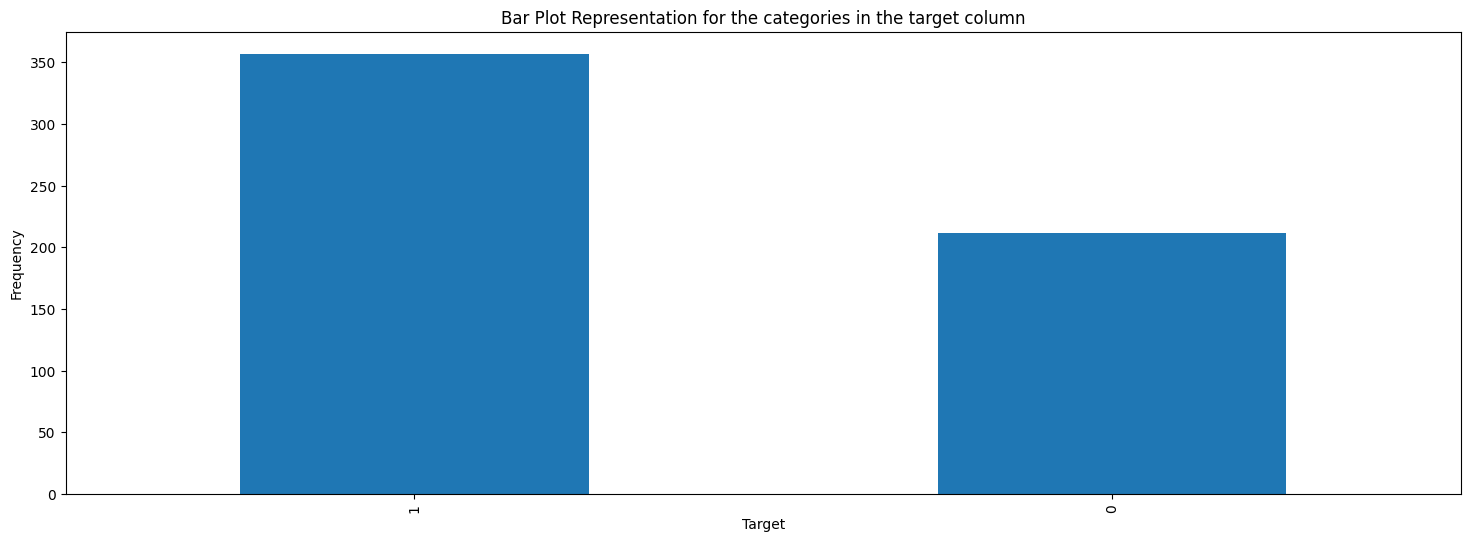

In [630]:
#### perform the graphical visualization for the categorical count of all the categories in the target column

plt.figure(figsize=(18,6))
df['target'].value_counts().plot(kind='bar')
#### get the title of the graph
plt.title("Bar Plot Representation for the categories in the target column")
#### get the x axis of the graph
plt.xlabel("Target")
#### get the y-axis of the graph
plt.ylabel("Frequency")
#### display the graph
plt.show()

#### OBSERVATIONS:

1.  The above graph depicts the frequency count of eac category in the target column.

2.  The count of target 1 is 357 and the count of target 2 is 212.

3.  So the target 1 is much higher in number than the target 2.

#### Step 4: Perform Data Cleaning and Feature Engineering

In [631]:
#### To check for all the NULL records in the dataset

df.isnull().sum()

mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
target                     0
dtype: int64

#### OBSERVATIONS:

1.  There are no null records used in the dataset.

In [632]:
#### To check for the duplicate records in the dataset

df[df.duplicated()]

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target


#### OBSERVATIONS:

1.  There are no duplicate records in the dataset.

In [633]:
#### Drop the unwanted column from the dataset

df.drop(columns='target',inplace=True)

#### OBSERVATIONS:

1.  The column 'target' has been removed from the dataset. This is because

    (a.) target is the dependent variable of the dataset. But here we are performing an unsupervised anamoly detection algorithm named "Local Outlier Factor (LOF)"

    (b.) As we are performing LOF algorithm on the data, it will work on the input not on the output.

    (c.) LOF will not produce any target values during the model training.  

In [634]:
#### Again check the data

df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


#### OBSERVATIONS:

1.  The target column has been completely removed from the dataset.

In [635]:
#### Select only the relevant input features

X = df[['mean radius', 'mean texture']]

In [636]:
X

,mean radius,mean texture
0,17.99,10.38
1,20.57,17.77
2,19.69,21.25
3,11.42,20.38
4,20.29,14.34
...,...,...
564,21.56,22.39
565,20.13,28.25
566,16.60,28.08
567,20.60,29.33


#### OBSERVATIONS:

1.  The 'mean radius' and 'mean texture' are the two important input features selected from the dataset.

In [637]:
df = X

#### Step 5: Perform Exploratory Data Analysis

In [638]:
#### get the correlation between all the numerical columns used in the dataset

df.corr()

,mean radius,mean texture
mean radius,1.000000,0.323782
mean texture,0.323782,1.000000


#### OBSERVATIONS:

1.  The above table explains the correlation for each numerical column with respect to each other in the dataset.

2.  The correlation between mean texture and mean radius is very less

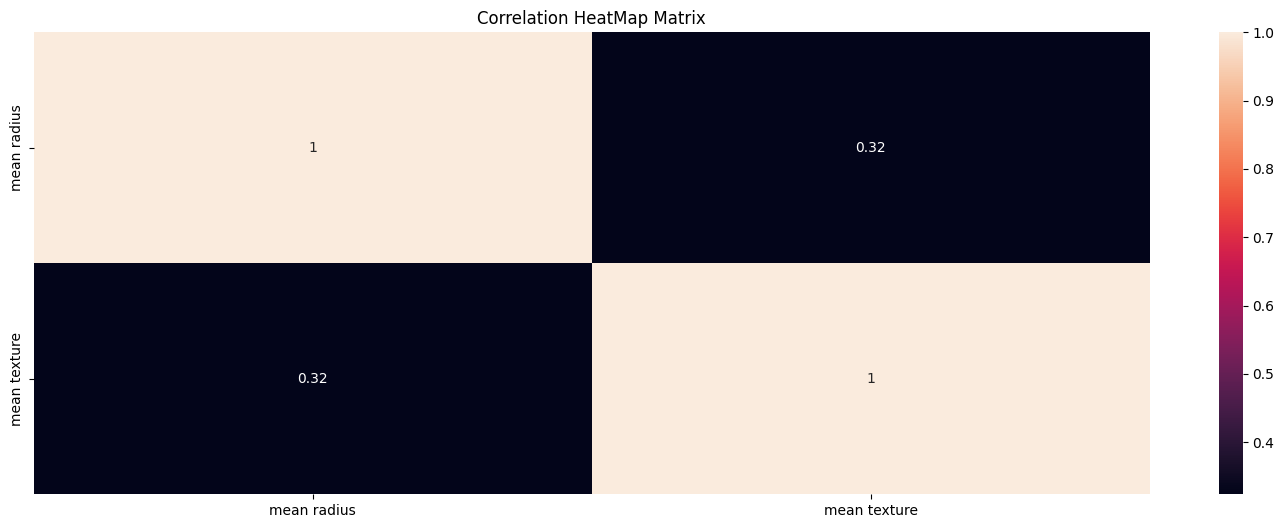

In [639]:
#### get the graphical representation for the correlation between all the numerical columns used in the dataset

plt.figure(figsize=(18,6))
sns.heatmap(df.corr(),annot=True)
plt.title("Correlation HeatMap Matrix")
plt.show()

#### OBSERVATIONS:

1.  The above table depicts the graphical representation for the correlation between the numrical columns used in the dataset.

#### Step 6: Divide the dataset into training and testing data

In [640]:
from    sklearn.model_selection import train_test_split

X_train, X_test = train_test_split(
    X                           ,
    test_size       =   0.2     ,
    random_state    =   42
)

In [641]:
X_train

,mean radius,mean texture
68,9.029,17.33
181,21.090,26.57
63,9.173,13.86
248,10.650,25.22
60,10.170,14.88
...,...,...
71,8.888,14.64
106,11.640,18.33
270,14.290,16.82
435,13.980,19.62


In [642]:
X_test

,mean radius,mean texture
204,12.47,18.60
70,18.94,21.31
131,15.46,19.48
431,12.40,17.68
540,11.54,14.44
...,...,...
486,14.64,16.85
75,16.07,19.65
249,11.52,14.93
238,14.22,27.85


#### OBSERVATIONS:

1.  The train test split function is applied on the input data ('X') as the Elliptic Envelop algorithm is an unsupervised anamoly based algorithm that does not use output label for prediction.

2.  So only X_train and X_test are only formed.

#### Step 7: Perform Feature Scaling on the inputs

In [643]:
from sklearn.preprocessing  import  StandardScaler

#### create an object for Standard Scaler

sc = StandardScaler()

#### using the object of standard sacler, transform the inputs

X_train_scaled = sc.fit_transform(X_train)

X_test_scaled  = sc.transform(X_test)

In [644]:
X_train_scaled

array([[-1.44075296e+00, -4.35319470e-01],
       [ 1.97409619e+00,  1.73302577e+00],
       [-1.39998202e+00, -1.24962228e+00],
       [-9.81796783e-01,  1.41622208e+00],
       [-1.11769991e+00, -1.01025950e+00],
       [ 1.19584794e-01,  1.96065509e+00],
       [ 8.27776975e-02,  1.27887086e-01],
       [-7.60954205e-01, -8.90578102e-01],
       [-5.28786366e-01, -2.92171137e-01],
       [ 1.63433838e+00,  2.52261867e-01],
       [-4.97641900e-01,  6.13652740e-01],
       [ 1.97692750e+00,  3.13275910e-01],
       [ 2.13018192e-01, -5.90201273e-01],
       [-1.26011506e+00, -1.63102968e-01],
       [-2.03185128e-01, -5.24493841e-01],
       [ 1.45879684e+00,  1.70955883e+00],
       [ 1.09638851e+00, -2.06627179e+00],
       [ 3.12114221e-01,  2.68343683e+00],
       [ 4.03079709e-02, -2.38197175e-01],
       [-6.84508697e-01, -1.76079412e-02],
       [ 3.26270797e-01, -1.47255821e+00],
       [ 3.46090003e-01, -1.15575452e+00],
       [-1.72040662e-01, -6.92352088e-02],
       [-1.

In [645]:
X_test_scaled

array([[-0.46649743, -0.13728933],
       [ 1.36536344,  0.49866473],
       [ 0.38006578,  0.06921974],
       [-0.48631664, -0.35318518],
       [-0.72980974, -1.11351403],
       [ 1.83536175,  2.38071331],
       [ 2.23457718,  0.63711968],
       [ 0.97747327, -0.9703657 ],
       [-0.22017302, -0.78028349],
       [-0.06161937, -0.60193474],
       [-0.25698012,  1.42326216],
       [ 0.75379938, -0.09035545],
       [ 0.24133134,  0.13492717],
       [ 0.60657099,  0.63242629],
       [-0.50330453, -1.62274662],
       [ 1.41066448,  1.66731834],
       [ 0.1960303 , -1.05249999],
       [-1.12053122,  0.09503337],
       [-2.0206063 , -1.35053012],
       [ 1.82120517,  0.39306351],
       [-0.08993252, -0.79671034],
       [-0.57125609, -0.3437984 ],
       [ 2.12132458,  0.72629405],
       [-1.15733832,  0.49162465],
       [-0.71282185,  1.24491342],
       [-0.16637803, -1.93485692],
       [-0.23716091, -1.282476  ],
       [-1.08372413,  1.97708194],
       [-0.3843893 ,

#### OBSERVATIONS:

1.  Ellyptic Envelope uses distiance based calculation, so feature scaling is used here.

#### Step 8: Create an object for Ellyptic Envelope model

In [646]:
ell_env = EllipticEnvelope(
    contamination   =   0.05    ,
    random_state    =   42
)

In [647]:
#### using the object of Ellyptic envelop, train the model

In [648]:
ell_env.fit(X_train_scaled)

EllipticEnvelope(contamination=0.05, random_state=42)

#### OBSERVATIONS:

1.  The object for Ellyptic Envelope has been created with the help of the following parameters :-----

    (a.)    contamination = 0.05 ================>  expected proportions of anamolies

    (b.)    random_state = 42   =================>  ensures reproducibility

2. Using the object, the model is trained using the training data.

#### Step 9: Predict the model

In [649]:
Y_pred = ell_env.predict(X_test_scaled)

In [650]:
Y_pred

array([ 1,  1,  1,  1,  1, -1, -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1, -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1, -1,  1,  1,  1,  1, -1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1, -1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1, -1,  1,  1,  1,  1,  1, -1])

#### OBSERVATIONS:

1.  The output is predicted for the given input test data.

2.  The predictions are in form of :---

    (a.)    1 ==============>  normal data

    (b.)    -1 =============>  outliers

3.  We need to convert the prediction into the labels in form of 1 and 0 for model evaluation as 0 and 1 are used for binary classification problems.

#### Step 10: Convert the predictions into labels

In [651]:
labels = np.where(Y_pred == -1,1,0)

In [652]:
labels

array([0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 1])

#### OBSERVATIONS:

1.  The labels are obtained in the form of 0 and 1 where

    (a.)    normal transactions =================>   0

    (b.)    outliers            =================>   1

#### Step 11: Perform the Visualizations of the Outliers

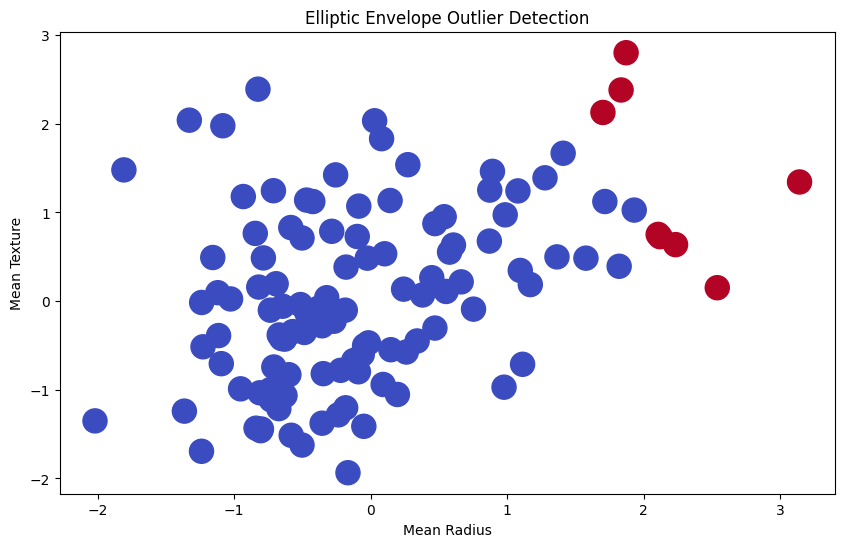

In [653]:
plt.figure(figsize=(10,6))

#### perform the scatterplot of the outliers
plt.scatter(
    X_test_scaled[:,0]           ,
    X_test_scaled[:,1]           ,
    c    =   labels              ,
    cmap = 'coolwarm'            ,
    s    =  300
)

plt.xlabel("Mean Radius")
plt.ylabel("Mean Texture")
plt.title("Elliptic Envelope Outlier Detection")
plt.show()

#### OBSERVATIONS:

1.  The above graph depicts that the normal data points have one color and the anamoly data point have another color.

2.  The model creates an ellipse boundary around the normal data point and any other point beyond the ellipse boundary is considered to be an anamoly.

#### Step 12: Get the anamoly score

In [654]:
#### Anamoly score

score = ell_env.decision_function(X_test_scaled)

In [655]:
print("Anamoly score for this model is:", score)

Anamoly score for this model is: [ 11.88996949   5.86934746  10.98923681  11.86047981  10.60717503
  -3.101713    -2.17743103   6.44691658  11.40221144  11.50827032
   8.4774668    9.4908077   11.33116374   9.81699728   9.16123591
   3.14165151   9.96674436  10.04131925   4.64239786   2.07867664
  11.22341946  11.7783714   -0.96725285   9.08037028   8.2415229
   7.38361468  10.17856554   2.58155195  11.93311767   7.4019914
   9.57549119   9.56741662   9.66762516  11.48874872  10.432407
  11.46281261   9.41412124  10.43067602   7.24702985   9.65269517
  10.49943787   7.98980593  11.2887658   11.61709148  11.67119524
  10.50330555   8.58672758   0.62243487  11.27043671  11.40441033
   8.66683411   4.90125656  10.70301172   9.42463613  10.82782304
  11.96756683  10.38626761 -14.53430499  11.57544412   9.62541382
  11.95102766   4.2331859   -0.83049606   6.70062894  11.80113106
   9.45175809   9.78632451   2.40181856  11.64086188  11.90577699
  10.91580848  10.51432158  11.60536717   9.960

#### OBSERVATIONS:

1.  Anamoly score interpretation

| Score    | Meaning |
| -------- | ------- |
| Positive | Normal  |
| Negative | Outlier |


#### Step 13: Visualizing the anamoly score

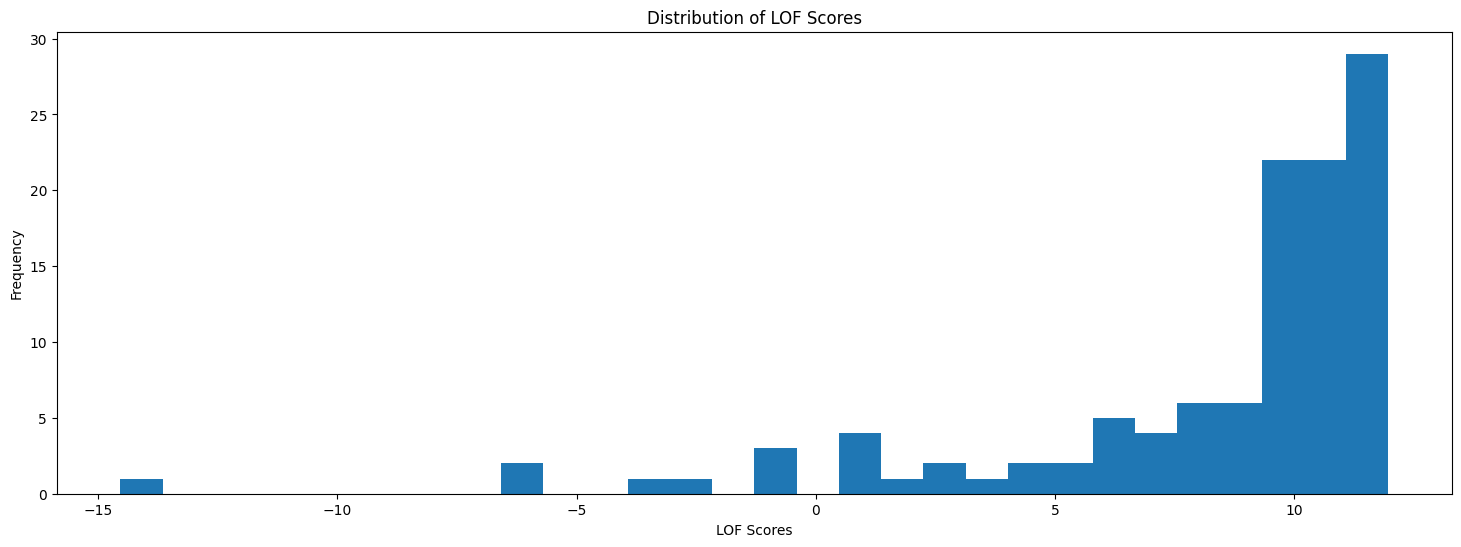

In [656]:
plt.figure(figsize=(18,6))

#### plot the lof scores
plt.hist(score, bins=30)

#### get the title of the graph
plt.title("Distribution of LOF Scores")

#### get the x-axis of the graph
plt.xlabel("LOF Scores")

#### get the y-axis of the graph
plt.ylabel("Frequency")

#### display the graph
plt.show()

#### OBSERVATIONS:

1.  From the above graph we can see that the normal data points are much higher in number than the anamoly.